In [1]:
import oqupy
import oqupy.operators as op
import numpy as np
import matplotlib.pyplot as plt
import time

import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'tmax':0.5,
                 'steps':50, 
                 'dkmax':50,
                 'epsrel':10**(-5),
                 'alpha':0.05,
                 'omega_cutoff':2.0*np.pi*5.0,                 
                 'temp':0.0}


opt_parameters = {'x0': pt_parameters['omega_cutoff'],
                'z0': 0.0,
                'lbx':2.0*np.pi*0.0,
                'ubx':2.0*np.pi*10.0,
                'lbz':0.0,
                'ubz':0.0,
                'initial_state':'mixed',
                'target_state':'x-'}


omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
t_max = pt_parameters['tmax']
# dt = 1./omega_cutoff/np.sqrt(3)
num_steps = pt_parameters['steps']
dt = t_max/num_steps
dkmax = pt_parameters['dkmax']

initial_state = op.spin_dm('mixed')
target_state = op.spin_dm('x-')
target_derivative = target_state.T

t_list = np.linspace(0,t_max,num_steps+1)


In [2]:
import oqupy as oqupy
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
import numpy as np
import matplotlib.pyplot as plt

correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=dkmax)
#pt=oqupy.pt_tempo_compute(
#    bath=bath,
#    start_time=0.0,
#    end_time=t_max,
#   parameters=parameters)
pt=TTITempo(bath,start_time=0.0,parameters=parameters)
process_tensor_tebd = pt.get_process_tensor()

building influence functional: 100%|██████████| 50/50 [00:00<00:00, 3968.65it/s]

rank  11


In [3]:
print(process_tensor_tebd._first_mpo_tensor.shape)
print(process_tensor_tebd._mpo_tensor.shape)

(1, 11, 4, 4)
(11, 11, 4, 4)


--> Compute dynamics:
  0.0%    0 of   50 [----------------------------------------] 00:00:00(1, 11, 4, 4)
  2.0%    1 of   50 [----------------------------------------] 00:00:00(11, 11, 4, 4)
  4.0%    2 of   50 [#---------------------------------------] 00:00:00(11, 11, 4, 4)
  6.0%    3 of   50 [##--------------------------------------] 00:00:00(11, 11, 4, 4)
  8.0%    4 of   50 [###-------------------------------------] 00:00:00(11, 11, 4, 4)
 10.0%    5 of   50 [####------------------------------------] 00:00:00(11, 11, 4, 4)
 12.0%    6 of   50 [####------------------------------------] 00:00:00(11, 11, 4, 4)
 14.0%    7 of   50 [#####-----------------------------------] 00:00:00(11, 11, 4, 4)
 16.0%    8 of   50 [######----------------------------------] 00:00:00(11, 11, 4, 4)
 18.0%    9 of   50 [#######---------------------------------] 00:00:00(11, 11, 4, 4)
 20.0%   10 of   50 [########--------------------------------] 00:00:00(11, 11, 4, 4)
 22.0%   11 of   50 [########----

(-5.0, 1.0)

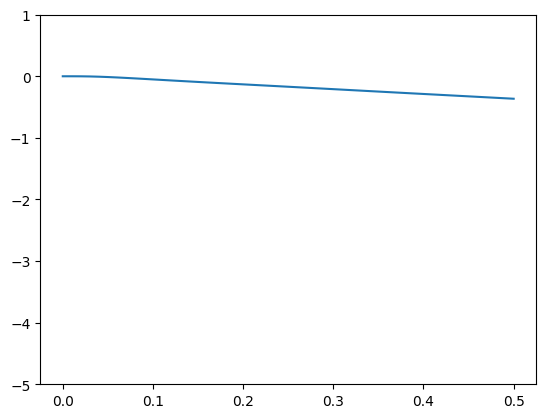

In [4]:
def hamiltonian_t(t):
    return pt_parameters['omega_cutoff']*op.sigma('x')/2 + 0.0*op.sigma('z')/2

system = oqupy.TimeDependentSystem(hamiltonian_t)

Rho_0=oqupy.operators.spin_dm('mixed')

dynamics = oqupy.compute_dynamics(
       process_tensor=process_tensor_tebd,        
       system=system,
       initial_state=Rho_0,
       start_time=0,
       num_steps=num_steps)

t, s_x = dynamics.expectations(op.sigma('x'), real=True)

plt.plot(t,np.log10(np.array(s_x)+1),label='sx')
plt.ylim((-5.0,1.0))


In [5]:
from oqupy.system_dynamics import _get_caps
_get_caps([process_tensor_tebd],2)


[array([-9.96737051e-01-8.07170947e-02j, -1.18169363e-14-1.61537450e-14j,
        -1.43496326e-14-3.48610030e-14j, -2.07334150e-14-2.38697950e-14j,
         6.10622664e-15+9.28424004e-15j, -2.72004641e-15-1.23234756e-14j,
         3.99680289e-15+7.21644966e-16j, -3.79928788e-05-3.07671395e-06j,
         2.60398964e-06+2.10874551e-07j,  3.80549819e-06+3.08174315e-07j,
        -1.54498810e-18-2.90024081e-18j])]

In [6]:
def discrete_hamiltonian(hx,hz):
    return hx*op.sigma('x')/2 + hz*op.sigma('z')/2
system = oqupy.ParameterizedSystem(discrete_hamiltonian)

h_z = np.ones(2*num_steps)*0 
h_x = np.ones(2*num_steps)*omega_cutoff

parameters = np.vstack((h_x,h_z)).T
parameters.shape


grad_res = oqupy.state_gradient(
    system=system,
    initial_state=initial_state,
    target_derivative=target_derivative,
    process_tensors=[process_tensor_tebd,process_tensor_tebd],
    num_steps=30,
    parameters=parameters)


--> Compute forward propagation:
  0.0%    0 of   30 [----------------------------------------] 00:00:00(1, 11, 4, 4)
(1, 11, 4, 4)
  3.3%    1 of   30 [#---------------------------------------] 00:00:00(11, 11, 4, 4)
(11, 11, 4, 4)
  6.7%    2 of   30 [##--------------------------------------] 00:00:00(11, 11, 4, 4)
(11, 11, 4, 4)
 10.0%    3 of   30 [####------------------------------------] 00:00:00(11, 11, 4, 4)
(11, 11, 4, 4)
 13.3%    4 of   30 [#####-----------------------------------] 00:00:00(11, 11, 4, 4)
(11, 11, 4, 4)
 16.7%    5 of   30 [######----------------------------------] 00:00:00(11, 11, 4, 4)
(11, 11, 4, 4)
 20.0%    6 of   30 [########--------------------------------] 00:00:00(11, 11, 4, 4)
(11, 11, 4, 4)
 23.3%    7 of   30 [#########-------------------------------] 00:00:00(11, 11, 4, 4)
(11, 11, 4, 4)
 26.7%    8 of   30 [##########------------------------------] 00:00:00(11, 11, 4, 4)
(11, 11, 4, 4)
 30.0%    9 of   30 [############---------------------------

In [9]:
# some code for behind the scenes use to see what comes back from the gradient calculation

grad_prop, dynamics = oqupy.compute_gradient_and_dynamics(
    system=system,
    initial_state=initial_state,
    target_derivative=target_derivative,
    process_tensors=[process_tensor_tebd],
    parameters=parameters,
    start_time=0.0,
    dt=dt,
    num_steps=27,
    progress_type=None)


--> Compute forward propagation:
  0.0%    0 of   27 [----------------------------------------] 00:00:00(1, 11, 4, 4)
  3.7%    1 of   27 [#---------------------------------------] 00:00:00(11, 11, 4, 4)
  7.4%    2 of   27 [##--------------------------------------] 00:00:00(11, 11, 4, 4)
 11.1%    3 of   27 [####------------------------------------] 00:00:00(11, 11, 4, 4)
 14.8%    4 of   27 [#####-----------------------------------] 00:00:00(11, 11, 4, 4)
 18.5%    5 of   27 [#######---------------------------------] 00:00:00(11, 11, 4, 4)
 22.2%    6 of   27 [########--------------------------------] 00:00:00(11, 11, 4, 4)
 25.9%    7 of   27 [##########------------------------------] 00:00:00(11, 11, 4, 4)
 29.6%    8 of   27 [###########-----------------------------] 00:00:00(11, 11, 4, 4)
 33.3%    9 of   27 [#############---------------------------] 00:00:00(11, 11, 4, 4)
 37.0%   10 of   27 [##############--------------------------] 00:00:00(11, 11, 4, 4)
 40.7%   11 of   27 [#